### Load and Modify Configuration File

In [1]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
x0 : 0.9
y0 : 1.5
T : 2.5
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : tanh
N_epochs : 50000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : no_reg
reg_coeff : 0
reg_decay : 1
reg_epochs : 0.6


### Initialize Physics-Informed Neural Network

In [2]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

2024-11-23 21:33:27.311811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-23 21:33:27.323115: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732394007.334966  121553 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732394007.338459  121553 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-23 21:33:27.352808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Model: "nested_PINN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,852 (30.67 KB)

 Trainable params: 7,852 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***


### Train Physics-Informed Neural Network

In [3]:
training_log = PINN.train()

Training started...
    0/50000 | loss: 3.07e+00
 1000/50000 | loss: 1.03e-03
 2000/50000 | loss: 4.08e-04
 3000/50000 | loss: 1.48e-04
 4000/50000 | loss: 3.26e-03
 5000/50000 | loss: 8.32e-04
 6000/50000 | loss: 5.43e-05
 7000/50000 | loss: 1.15e-04
 8000/50000 | loss: 3.30e-04
 9000/50000 | loss: 3.13e-05
10000/50000 | loss: 8.66e-04
11000/50000 | loss: 9.99e-05
12000/50000 | loss: 9.54e-04
13000/50000 | loss: 9.55e-04
14000/50000 | loss: 5.24e-05
15000/50000 | loss: 9.57e-05
16000/50000 | loss: 2.89e-05
17000/50000 | loss: 7.23e-05
18000/50000 | loss: 1.86e-05
19000/50000 | loss: 1.15e-04
20000/50000 | loss: 4.47e-06
21000/50000 | loss: 7.41e-05
22000/50000 | loss: 5.99e-06
23000/50000 | loss: 2.56e-05
24000/50000 | loss: 2.81e-06
25000/50000 | loss: 3.86e-06
26000/50000 | loss: 2.42e-05
27000/50000 | loss: 1.32e-05
28000/50000 | loss: 8.80e-06
29000/50000 | loss: 2.12e-06
30000/50000 | loss: 1.60e-06
31000/50000 | loss: 1.54e-06
32000/50000 | loss: 1.54e-06
33000/50000 | loss: 1.5

# Plot Section

In [4]:
from model.plots import learning_curves, toy_example_dynamics, loss_over_tcoll, plot_regularization

### Learning Curves

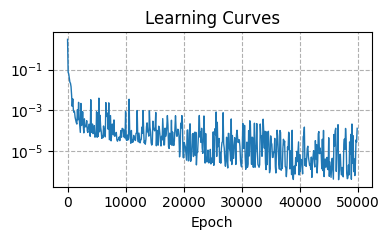

In [5]:
learning_curves(training_log)

### Toy Example Dynamics

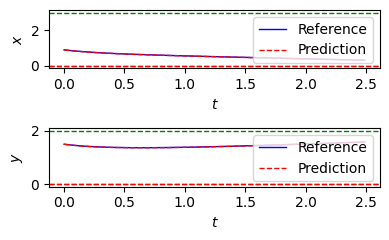

In [6]:
toy_example_dynamics(PINN)

(250, 1)
(250, 2)
TensorShape([250])


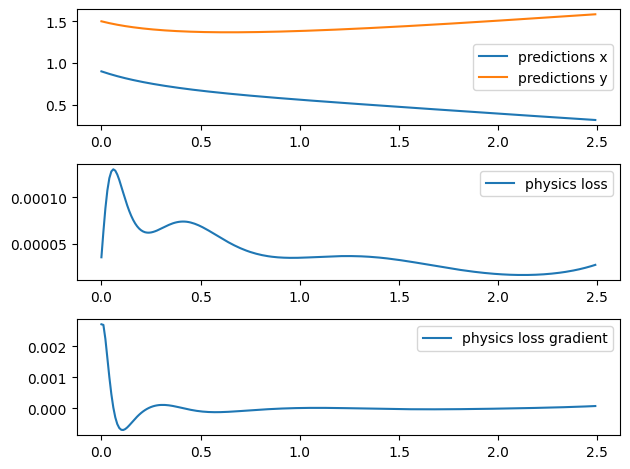

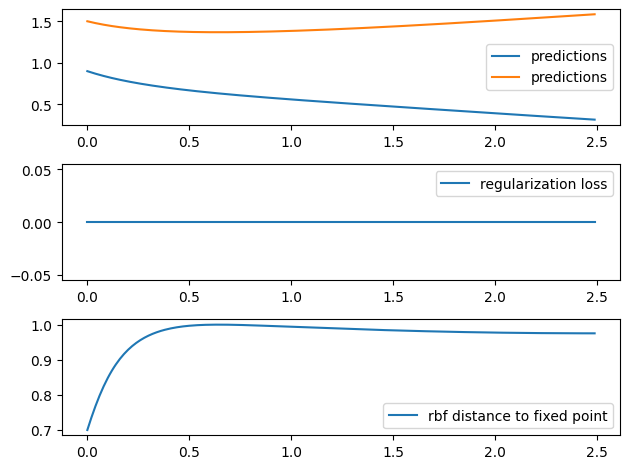

In [7]:
import tensorflow as tf

t_col = PINN.data.t_line()
pred = PINN(t_col)

print(t_col.shape)
print(pred.shape)

loss_over_tcoll(PINN)

plot_regularization(PINN)


### Training animation

In [8]:
import matplotlib.pyplot as plt
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, ax = plt.subplots()

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, ax


def animate(i, *fargs):
    # get passed arguments
    ax = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    ax.clear()

    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))
    # get (equally-spaced) data points
    t_line = PINN.data.t_line()
    # get reference solution (analytical)
    y_true = PINN.data.reference(t_line)
    # get PINN prediction
    y_pred = PINN(t_line)

    #############################
    ### Updated plot comes here
    #############################

    # include fixed point lines
    for y_fix in [-1, 1]:
        ax.axhline(y_fix, lw=1, ls='--', c='green')
    ax.axhline(0, lw=1, ls='--', c='red')

    # make plots
    ax.plot(t_line, y_true, c='blue', lw=1, label='Reference')
    ax.plot(t_line, y_pred, c='red', lw=1, ls='--', label='Prediction')

    # Axis appearance
    ax.legend()
    ax.set_ylabel(r'$y$')
    ax.set_xlabel(r'$t$')


    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

TypeError: only integer scalar arrays can be converted to a scalar index

/home/mbabic/Desktop/PINNs_fixed_points/toy_example/model/plots.py:129: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  results["reg_decay"].fillna("no decay", inplace=True)


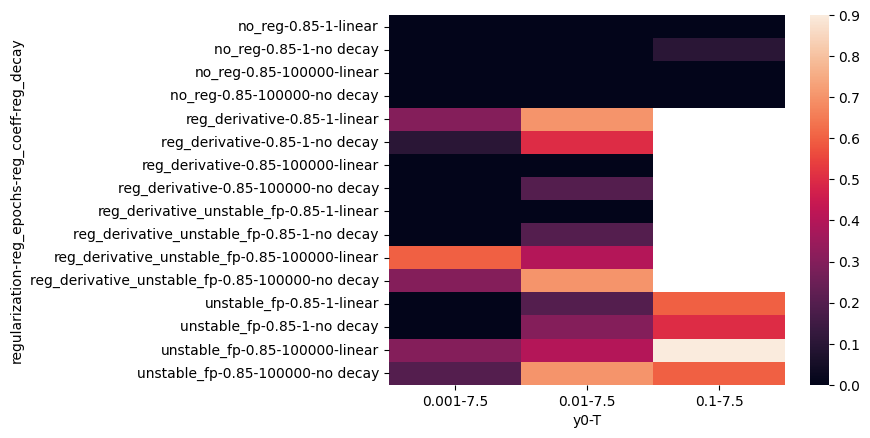

In [ ]:
import pandas as pd
import numpy as np
from model.plots import results_heatmap

results = pd.read_csv("results.csv")

results_heatmap(results)

2024-11-21 13:53:50.695034: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732193630.714588   20412 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732193630.719843   20412 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-21 13:53:50.737663: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


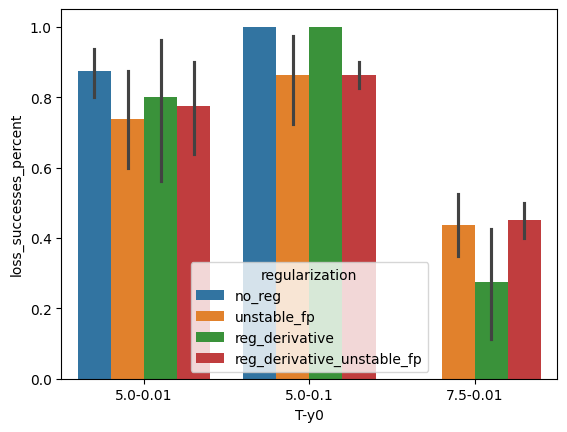

In [ ]:
from model.plots import plot_comparissons
import pandas as pd

results = pd.read_csv("results_linear_decay.csv")

plot_comparissons(results=results)

